In [36]:
# Library importation
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

In [ ]:
# Data
x = np.array([1, 3])
y = np.array([3, 6])

# Initial values
m = -1
b = 1
alpha = 0.1
iterations = 4

m_history = []
b_history = []
error_history = []

n = len(x)

# Cost function using SciPy-compatible format
def cost_function(params):
    m_val, b_val = params
    y_hat = m_val * x + b_val
    errors = y - y_hat
    J = (1/n) * np.sum(errors**2)
    return J

for i in range(iterations):

    # Cost (MSE)
    J = cost_function([m, b])

    # Gradients computed using SciPy
    grads = approx_fprime([m, b], cost_function, 1e-8)
    dm = grads[0]
    db = grads[1]

    # Update m and b using our learning rate alpha
    m = m - alpha * dm
    b = b - alpha * db

    # Store history
    m_history.append(m)
    b_history.append(b)
    error_history.append(J)

In [40]:
# Print m and b at each iteration
for i in range(len(m_history)):
    print(f"Iteration {i+1}: m = {m_history[i]:.4f}, b = {b_history[i]:.4f}")

Iteration 1: m = 1.7000, b = 2.1000
Iteration 2: m = 1.2600, b = 1.9000
Iteration 3: m = 1.3400, b = 1.9160
Iteration 4: m = 1.3336, b = 1.8968


In [22]:
# Final Predictions
final_predictions = m * x + b

print("Final m:", m)
print("Final b:", b)
print("Predictions:", final_predictions)

Final m: 1.5
Final b: 1.5000000000000004
Predictions: [3. 6.]


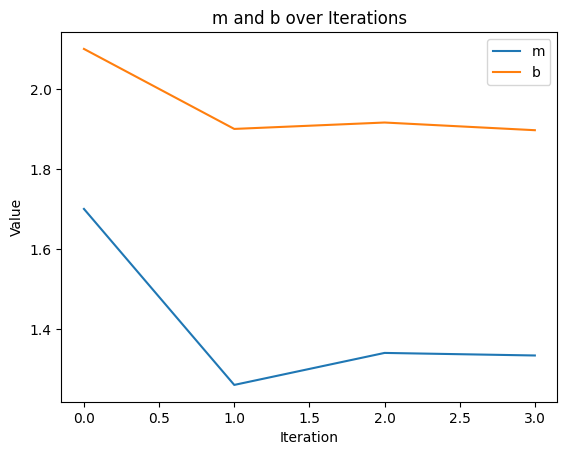

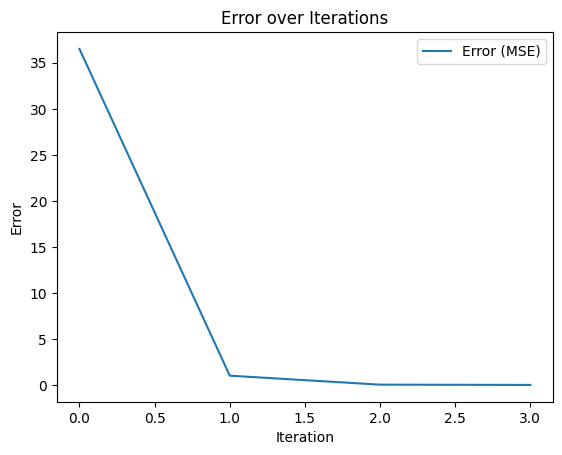

In [42]:
# Plot 1: m and b over iterations
plt.figure()
plt.plot(range(iterations), m_history, label='m')
plt.plot(range(iterations), b_history, label='b')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('m and b over Iterations')
plt.legend()
plt.show()

# Plot 2: Error over iterations
plt.figure()
plt.plot(range(iterations), error_history, label='Error (MSE)')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error over Iterations')
plt.legend()
plt.show()